# Загрузка файла

In [63]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords



df = pd.read_csv("data/vk_posts_raw.csv")
df["text"] = df["text"].fillna("").astype(str)

print("rows:", len(df))
df.head(5)

df["text_len"] = df["text"].str.len()
df["is_empty"] = df["text_len"] == 0

df[["domain", "post_id", "text_len", "is_empty"]].describe(include="all")


rows: 4999


,domain,post_id,text_len,is_empty
count,4999,4.999000e+03,4999.000000,4999
unique,5,NaN,NaN,2
top,poterjashkansk,NaN,NaN,False
freq,1000,NaN,NaN,4695
mean,NaN,4.713176e+05,569.238448,NaN
std,NaN,8.103382e+05,500.915251,NaN
min,NaN,1.334500e+04,0.000000,NaN
25%,NaN,5.849100e+04,250.500000,NaN
50%,NaN,7.810400e+04,374.000000,NaN
75%,NaN,1.164365e+05,859.000000,NaN


# Очистка исходных данных

In [64]:
try:
    _ = stopwords.words("russian")
except LookupError:
    nltk.download("stopwords")

STOP_RU = set(stopwords.words("russian"))

STOP_EXTRA = {
    # просьбы/платформа
    "пж","плиз","пожалуйста","срочно",
    "репост","репосты","репостните","репостить",
    "лс","личку","личные","сообщения","пишите","написать","писать","написать",
    "номер","телефон","звонить","звоните","whatsapp","ватсап","viber","вайбер","telegram","телеграм",
    "фото","фотографии","фотка","фотки","видео",
    "автор","группа","пост","бот","создана",

    # гео-общие слова (по желанию можно оставить, но обычно это шум)
    "город","район","улица","дом","адрес","области",
    "нск","nsk","новосибирск","нсо","москва","мск",

    # домены/бренды из постов
    "poterjashkansk","pet911","ios","android",
    "pet","911",  
}

STOP_SET = STOP_RU | STOP_EXTRA
len(STOP_SET)

PROMO_PATTERNS = [
    r"подробная\s+информация\s+здесь",
    r"потеряли\s+или\s+нашли\s+питомца\??",
    r"бесплатно\s+разместите\s+объявление\s+на\s+pet911",
    r"\bpet911\b",
]

import re

# --- маркеры "строки-мусор" (режем целыми строками) ---
AUTHOR_LINE_RE = re.compile(r"^\s*💬.*$", re.MULTILINE)   # 💬 Автор: ...
GEO_LINE_RE    = re.compile(r"^\s*📍.*$", re.MULTILINE)   # 📍 ул....
PHONE_LINE_RE  = re.compile(r"^\s*📞.*$", re.MULTILINE)   # если вдруг встречается

# --- промо Pet911: режем строками и/или по ссылкам ---
PET911_LINE_RE = re.compile(
    r"^\s*(потеряли\s+или\s+нашли\s+питомца\??|бесплатно\s+разместите\s+объявление\s+на\s+pet911|подробная\s+информация\s+здесь)\s*$",
    re.IGNORECASE | re.MULTILINE
)
PET911_LINK_RE = re.compile(r"https?://(www\.)?pet911\.ru/\S+", re.IGNORECASE)
VKCC_LINK_RE   = re.compile(r"https?://vk\.cc/\S+", re.IGNORECASE)

# --- остальная чистка ---
URL_RE = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
VK_MENTION_RE = re.compile(r"\[id\d+\|[^\]]+\]|\[club\d+\|[^\]]+\]", re.IGNORECASE)
HASHTAG_RE = re.compile(r"#\w+", re.IGNORECASE)
PHONE_RE = re.compile(r"(\+?\d[\d\-\s\(\)]{7,}\d)")
MULTISPACE_RE = re.compile(r"\s+")
NON_LETTERS_RE = re.compile(r"[^а-яёa-z\s-]", re.IGNORECASE)

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    t = text

    # 1) сначала вырезаем целые "служебные" строки до остальных замен
    t = AUTHOR_LINE_RE.sub(" ", t)   # 💬 Автор ...
    t = GEO_LINE_RE.sub(" ", t)      # 📍 ...
    t = PHONE_LINE_RE.sub(" ", t)    # 📞 ...
    t = PET911_LINE_RE.sub(" ", t)   # строки-промо
    t = PET911_LINK_RE.sub(" ", t)   # ссылки pet911
    t = VKCC_LINK_RE.sub(" ", t)     # короткие vk.cc

    # 2) дальше стандартная нормализация
    t = t.lower()
    t = URL_RE.sub(" ", t)           # любые ссылки (на всякий)
    t = VK_MENTION_RE.sub(" ", t)    # [id..|Name]
    t = HASHTAG_RE.sub(" ", t)       # #хэштеги
    t = PHONE_RE.sub(" ", t)         # телефоны
    t = t.replace("\n", " ").replace("\t", " ")

    # 3) оставляем только буквы/пробел/дефис
    t = NON_LETTERS_RE.sub(" ", t)
    t = MULTISPACE_RE.sub(" ", t).strip()
    return t



# Токенизация

In [65]:
def tokenize(text: str):
    if not text:
        return []
    return [w for w in text.split(" ") if w]

def filter_tokens(tokens):
    out = []
    for w in tokens:
        if len(w) < 3:
            continue
        if w in STOP_SET:
            continue
        out.append(w)
    return out

# Обработка текста (очистка и токенизация)

In [66]:
df["clean_text"] = df["text"].apply(normalize_text)
df["tokens"] = df["clean_text"].apply(tokenize).apply(filter_tokens)
df["final_text"] = df["tokens"].apply(lambda t: " ".join(t))

display(df.head(3))

empty_after = (df["final_text"].str.strip() == "").sum()
print("Пустых после обработки:", empty_after, "из", len(df))

df_nonempty = df[df["final_text"].str.strip() != ""].copy()
print("Осталось непустых:", len(df_nonempty))

,domain,post_id,text,text_len,is_empty,clean_text,tokens,final_text
0,poterjashkansk,2095257,"📍ул. Вертковская, Ленинский район\n⚠ОБНОВЛЕНО:...",733,False,обновлено утром видели в районе ост дюканова м...,"[обновлено, утром, видели, районе, ост, дюкано...",обновлено утром видели районе ост дюканова дви...
1,poterjashkansk,2096174,,0,True,,[],
2,poterjashkansk,2096171,"📍ул. Семьи Шамшиных / Орджоникидзе, Центральны...",417,False,бегает маленький гладкошерстный кобель прямо п...,"[бегает, маленький, гладкошерстный, кобель, пр...",бегает маленький гладкошерстный кобель прямо п...


Пустых после обработки: 347 из 4999
Осталось непустых: 4652


# Частоты слов

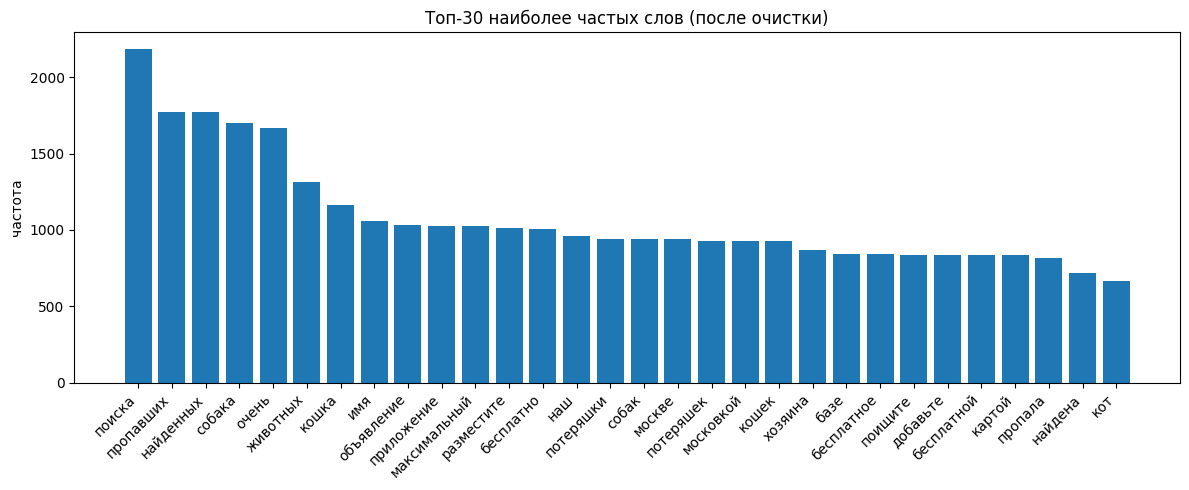

In [67]:
TOP_N = 30
freq = Counter()
for toks in df_nonempty["tokens"]:
    freq.update(toks)

top_words = freq.most_common(TOP_N)
top_words[:10]

labels = [w for w, c in top_words]
values = [c for w, c in top_words]

plt.figure(figsize=(12,5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title(f"Топ-{TOP_N} наиболее частых слов (после очистки)")
plt.ylabel("частота")
plt.tight_layout()
plt.show()
 

# Биграммы

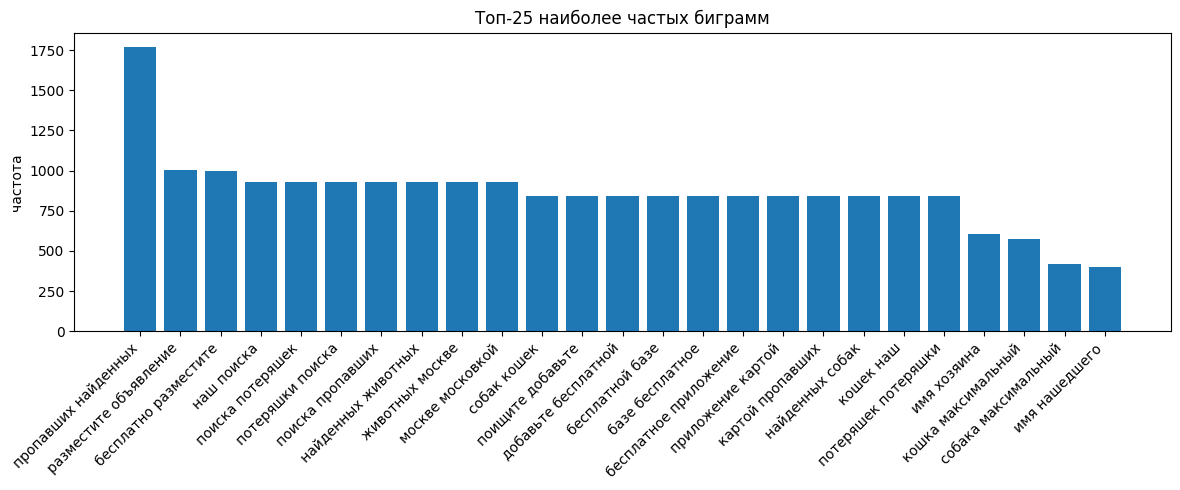

In [68]:
TOP_BI = 25
bi = Counter()

for toks in df_nonempty["tokens"]:
    for i in range(len(toks) - 1):
        bi[(toks[i], toks[i+1])] += 1

top_bi = [(" ".join(k), v) for k, v in bi.most_common(TOP_BI)]
top_bi[:10]

labels = [x[0] for x in top_bi]
values = [x[1] for x in top_bi]

plt.figure(figsize=(12,5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title(f"Топ-{TOP_BI} наиболее частых биграмм")
plt.ylabel("частота")
plt.tight_layout()
plt.show()

# Облако слов

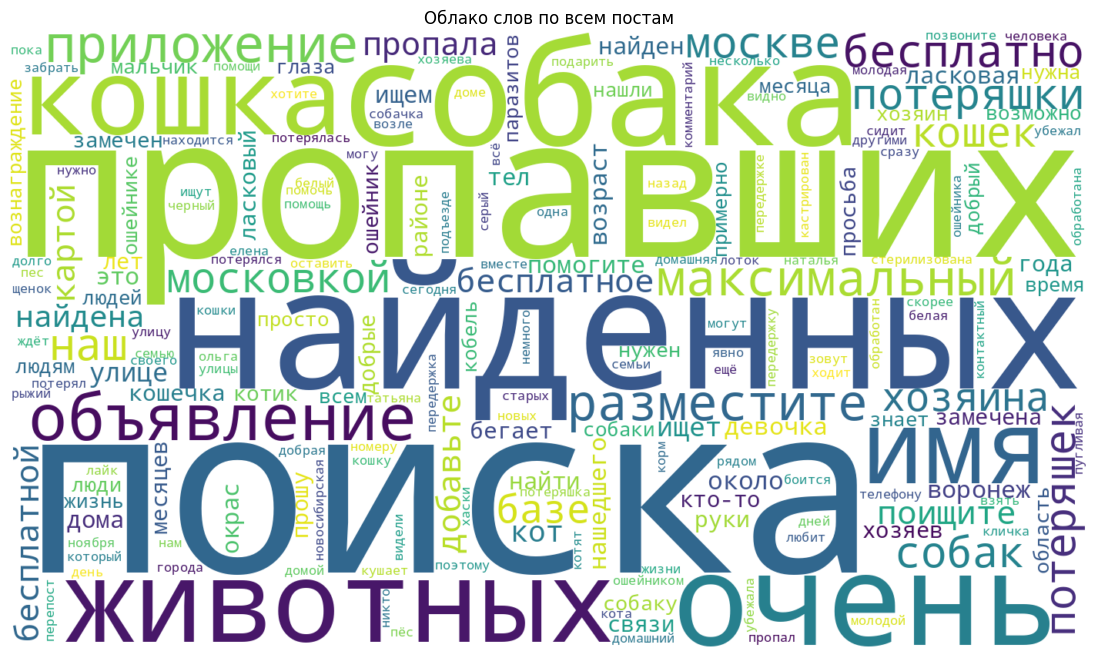

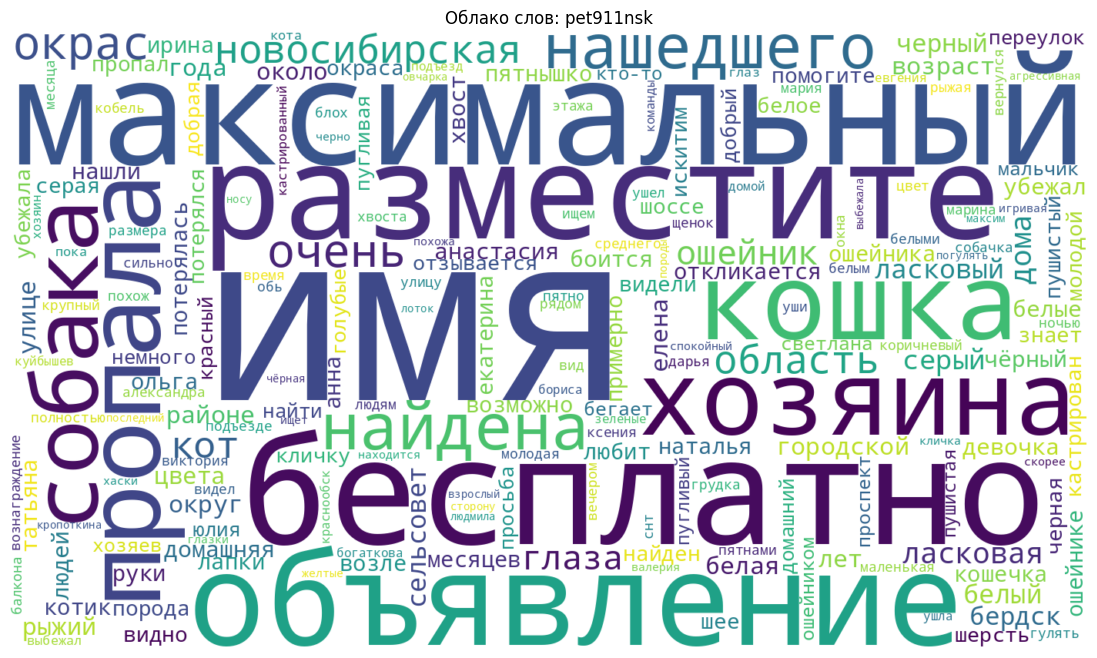

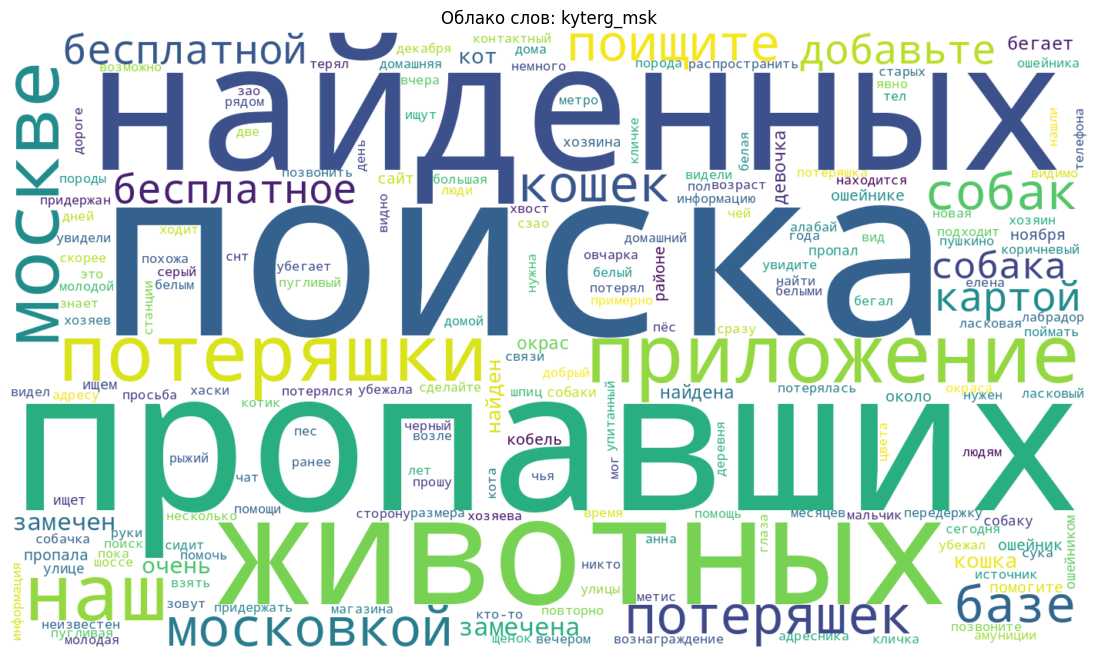

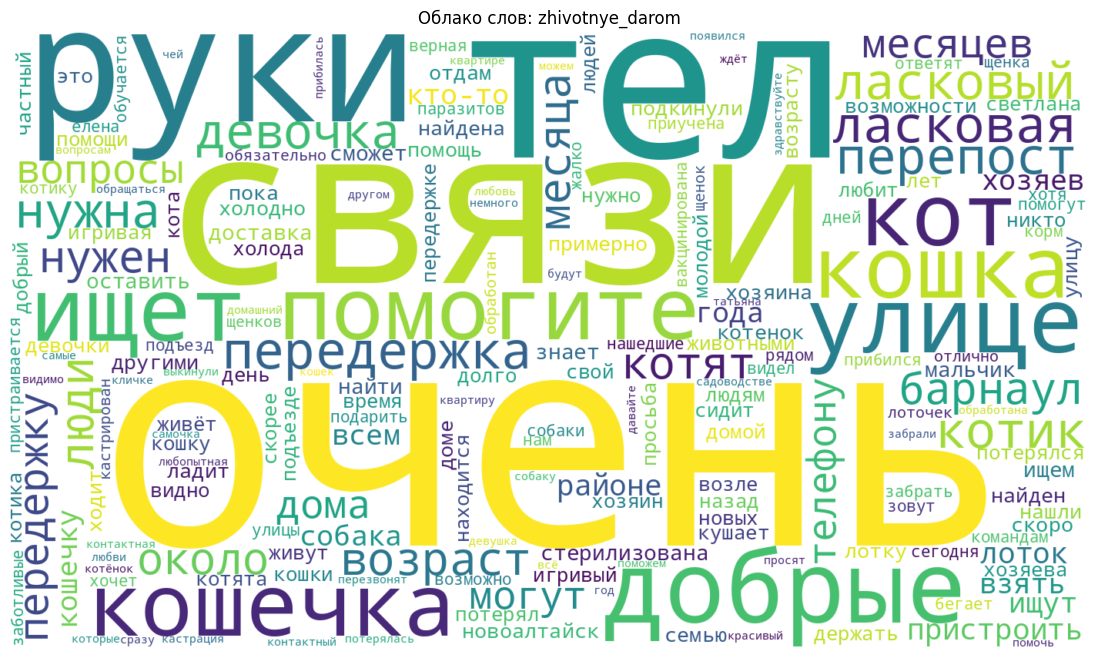

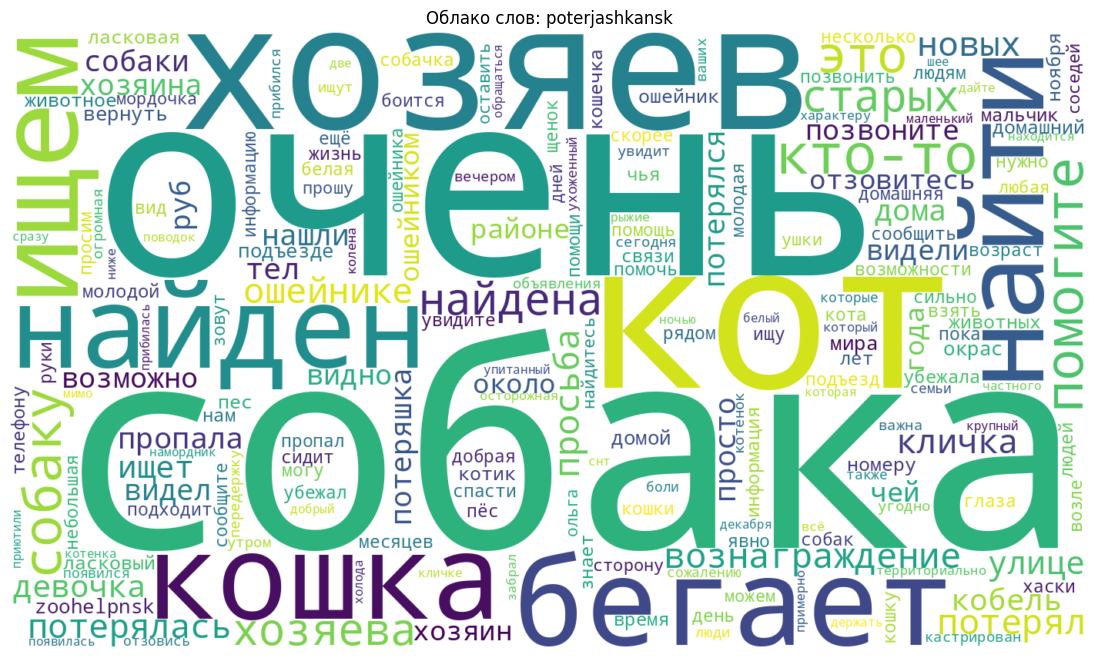

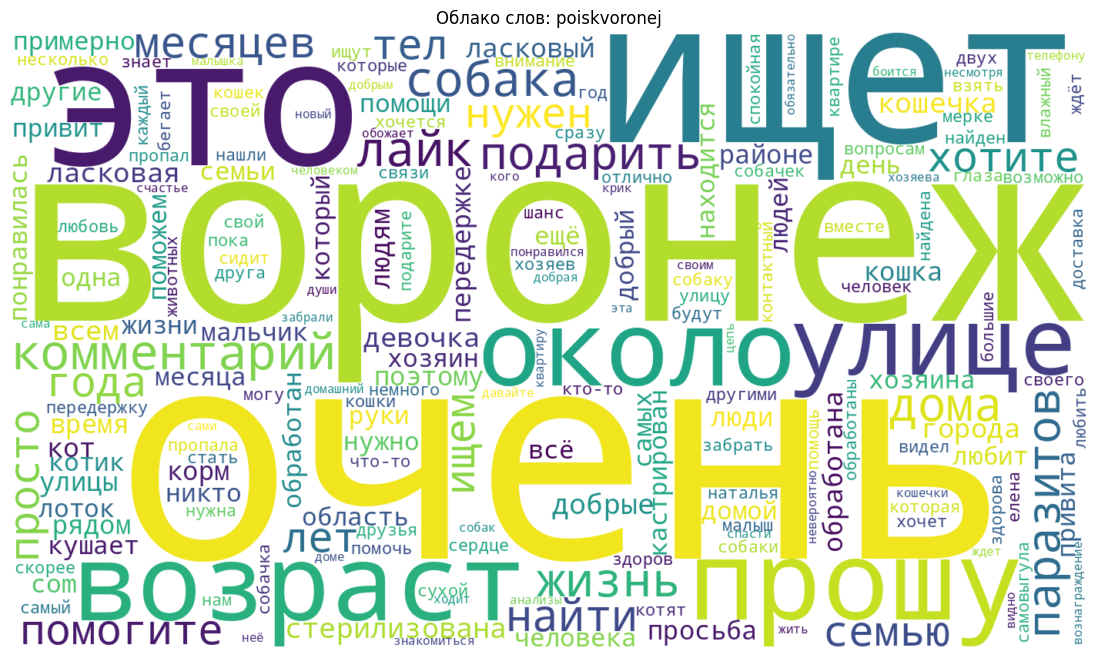

In [69]:
# Общее
wc = WordCloud(
    width=1400,
    height=800,
    background_color="white",
    collocations=False
).generate_from_frequencies(dict(freq))

plt.figure(figsize=(14,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов по всем постам")
plt.show()

# По группам в вк
top_domains = df_nonempty["domain"].value_counts().head(5).index.tolist()

for dom in top_domains:
    sub = df_nonempty[df_nonempty["domain"] == dom]
    f = Counter()
    for toks in sub["tokens"]:
        f.update(toks)

    wc_dom = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(dict(f))

    plt.figure(figsize=(14,8))
    plt.imshow(wc_dom, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов: {dom}")
    plt.show()

# TF-IDF

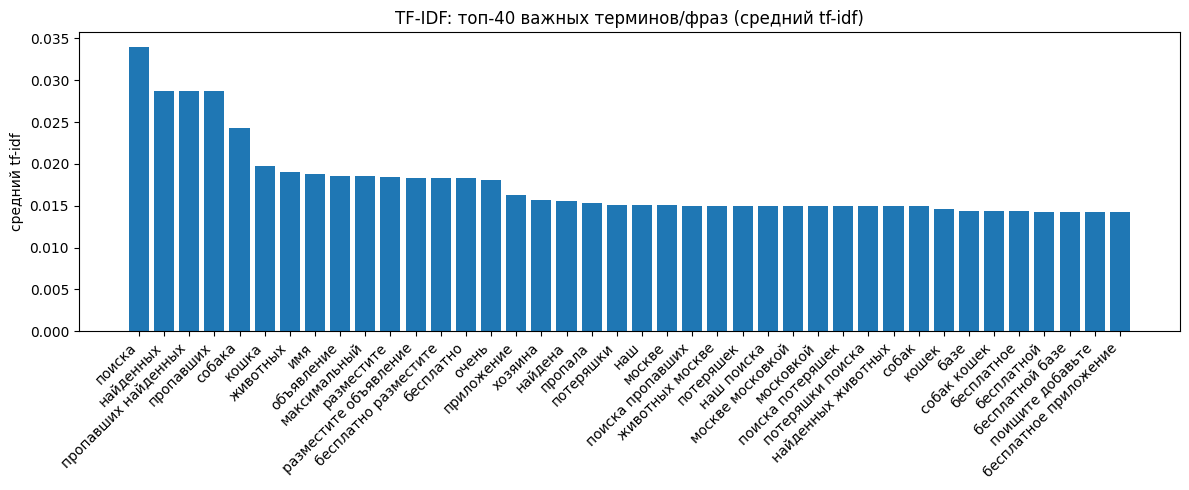

In [70]:
TFIDF_TOP = 40

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df_nonempty["final_text"])
terms = np.array(tfidf.get_feature_names_out())

mean_scores = np.asarray(X.mean(axis=0)).ravel()
top_idx = np.argsort(mean_scores)[::-1][:TFIDF_TOP]

tfidf_top = list(zip(terms[top_idx], mean_scores[top_idx]))
tfidf_top[:15]

labels = [t for t, s in tfidf_top]
values = [float(s) for t, s in tfidf_top]

plt.figure(figsize=(12,5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.title(f"TF-IDF: топ-{TFIDF_TOP} важных терминов/фраз (средний tf-idf)")
plt.ylabel("средний tf-idf")
plt.tight_layout()
plt.show()


# Кластеризация

# Подбор количества кластеров

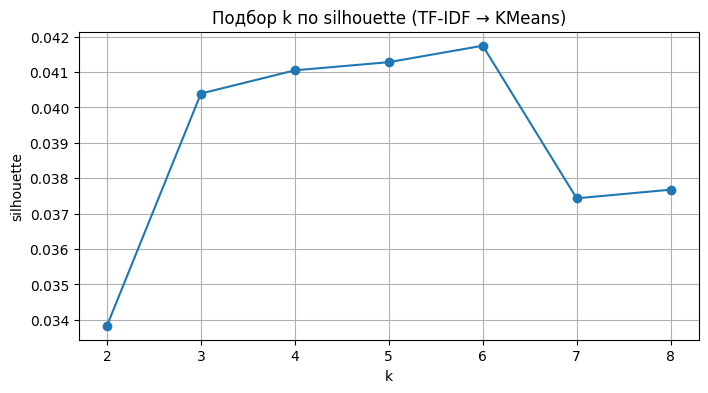

In [78]:
k_range = range(2, 9)
scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    scores.append(s)

plt.figure(figsize=(8,4))
plt.plot(list(k_range), scores, marker="o")
plt.title("Подбор k по silhouette (TF-IDF → KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True)
plt.show()

best_k = 3


## Визуализация кластеров


CLUSTER 0 | size = 991


['Найдена кошка! Пожалуйста, максимальный репост!\n\nМолодая, черно-белая кошка. Видно, что домашняя. У кошки стресс. Живет на данный момент, в подъезде.\nИмя нашедшего: Евгения\nТелефон: 79963811783\nАдрес: улица Челюскинцев, 6, Новосибирск\nПодробная информация здесь\nhttps://pet911.ru/rf1118152\n\nПотеряли или нашли питомца?\nБесплатно разместите объявление на Pet911 https://vk.cc/8POd59',
 'Найдена собака! Пожалуйста, максимальный репост!\n\nБегает нюхает следы ищет хозяина, серо рыжий\nИмя нашедшего: Константин\nТелефон: 79537922993\nАдрес: 9А, городской округ Искитим\nПодробная информация здесь\nhttps://pet911.ru/rf1118144\n\nПотеряли или нашли питомца?\nБесплатно разместите объявление на Pet911 https://vk.cc/8POd59',
 'Пропала собака! Пожалуйста, максимальный репост!\n\nПотерялась собачка, породы мини той терьер, убежала без ошейника, откликается на Боня, Бонечка,Боняша, потерялась в ложках около 19:00, 19.06, просим написать в личку, ватсап  или тг @ViktoryaKim25!! Может кто ви


CLUSTER 1 | size = 920


['Земляной вал39‼️Возможно, кто-то узнает Своего питомца‼️ Пожалуйста Репост‼️\n \n- - -\nПриложение Android для поиска животных\nhttps://ru.kyterg.com/~vkPostToAndroid\n\nПриложение iOS для поиска животных\nhttps://ru.kyterg.com/~VKPostToIOS\n\nНаш Телеграм БОТ для поиска потеряшек\nhttps://ru.kyterg.com/~vkPostToTgBot\n\nСайт поиска животных\nhttps://ru.kyterg.com/~VKPostToWeb\n\nМосква и МО - потеряшки - группа создана для поиска пропавших и найденных животных в Москве и Московкой области\n\n#потеряласьсобака #найденасобака #потеряласященок #найденщенок\n#потеряласькошка #найденакошка #потерялсякот #найденкот #потерялсякотенок #найденкотенок\n\n#Москва #МСК #МО #МосковскаяОбласть #МосковскаяОбласть #Балашиха #Химки #Подольск #Мытищи\n#Люберцы #Коломна #Одинцово #Серпухов #ОреховоЗуево #Красногорск #СергиевПосад #Щёлково #Пушкино\n#Ногинск #Раменское #Домодедово #Воскресенск #Долгопрудный #Реутов #Клин #Лобня #Дубна\n#НароФоминск #ПавловскийПосад #Дмитров #Чехов #Ивантеевка #Видное #


CLUSTER 2 | size = 2741


['📍ул. Вертковская, Ленинский район\n⚠ОБНОВЛЕНО: утром видели в районе ост. Дюканова, может двигаться в сторону г. Обь\n\n16.12 ночью/утром с территории частного дома сбежал кобель, кличка Игорь.\nРостом по колено, полностью белый, в коричневом кожаном ошейнике. В ухе бирка с номером "100". Не агрессивный.\nПристроен несколько дней назад - местности не знает, боится, в руки скорее всего не пойдет. Всю жизнь жил на территории частного дома, в городе будет вести себя непредсказуемо.\nПожалуйста, если увидите его - попытайтесь сфотографировать и позвоните +79139468977 Мария\n💬 Автор: [id36034959|Мария Сафрошкина] \n\n#пропаласобака2025@poterjashkansk\n#Ленинский@poterjashkansk \n#poterjashkansk #потеряшканск \n#потерянныеживотныеновосибирск',
 '📍ул. Семьи Шамшиных / Орджоникидзе, Центральный район\nБегает маленький гладкошерстный кобель прямо по проезжей части, кидается под машины, оглядывается по сторонам как будто кого-то ищет.\nЧей? \nНа улице капец как холодно, замерзнет парень, в рук

Cluster 0 top terms: имя, бесплатно разместите, разместите объявление, бесплатно, разместите, максимальный, объявление, имя хозяина, кошка максимальный, пропала, кошка, хозяина, собака максимальный, имя нашедшего, нашедшего
Cluster 1 top terms: поиска, найденных, пропавших, пропавших найденных, животных, приложение, потеряшки, москве, поиска потеряшек, московкой, поиска пропавших, наш поиска, найденных животных, животных москве, потеряшки поиска
Cluster 2 top terms: очень, кот, то, связи, тел, собака, ищет, помогите, найден, дома, бегает, руки, ищем, улице, хозяев


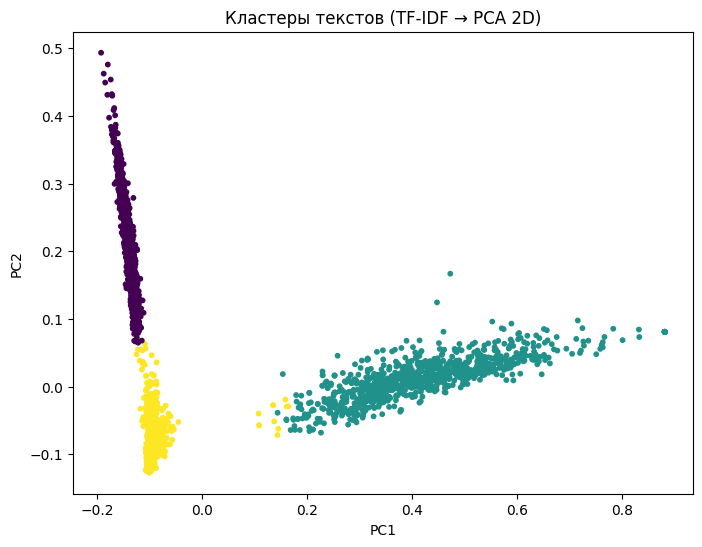

In [79]:
km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster = km.fit_predict(X)

df_nonempty["cluster"] = cluster
df_nonempty["cluster"].value_counts().sort_index()

# Покажем по 5 примеров текстов из каждого кластера
for c in sorted(df_nonempty["cluster"].unique()):
    print("\n" + "="*80)
    print("CLUSTER", c, "| size =", (df_nonempty["cluster"] == c).sum())
    examples = df_nonempty[df_nonempty["cluster"] == c]["text"].head(5).tolist()
    display(examples)


# Топ-термины по центроиду кластера в tf-idf пространстве
feature_names = np.array(tfidf.get_feature_names_out())

for c in range(best_k):
    center = km.cluster_centers_[c]
    top_idx = np.argsort(center)[::-1][:15]
    top_terms = feature_names[top_idx]
    print(f"Cluster {c} top terms:", ", ".join(top_terms))

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=df_nonempty["cluster"], s=10)
plt.title("Кластеры текстов (TF-IDF → PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()




